<a href="https://colab.research.google.com/github/Munfred/worm-markers/blob/master/make_swarmplots_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Looking for C. elegans neuronal markers using CeNGEN data
By Eduardo da Veiga Beltrame - edaveiga@caltech.edu - https://munfred.com 

Code repository: https://github.com/Munfred/worm-markers

This notebook creates interactive "swarm plots" to look for marker genes in C. elegans using the CeNGEN dataset of L4 neurons (http://cengen.org/) 

### Summary
This is a simple computational workflow for using single cell RNA sequencing (scRNAseq) data to identify promising marker gene candidates in C. elegans. This workflow leverages the scvi-tools package (https://scvi-tools.org), which uses deep learning to create a probabilistic model of gene expression in single cells. The workflow is composed of three steps: 

1) Training the scVI model on scRNAseq data;

2) Performing differential expression (DE) between the cell type of interest and all other cells;

3) Visualizing the relative expression levels of top DE genes across all cell types to identify promising candidates with an interactive plot.


### Workflow Description
In principle, there are only two features that make a “good” marker gene for a given cell type: having high specificity to the cell type of interest and having high expression. We reasoned that these features should be possible by using annotated scRNAseq data that includes the cell types of interest. 

By repeatedly sampling each cell, scVI allows the inference of transcript “rates”, corresponding to the fractions of transcripts sampled in a given cell that belong to each gene. This is akin to the normalized gene expression that is used in other scRNAseq processing frameworks. However, it is an inference instead of an empirically estimated value  obtained by for example dividing the number of transcripts sequenced in each cell by the total. We refer to it as the expression rate of a gene or simply expression of a gene.

We conceived the following three step workflow to look for high expression and high specificity genes using scVI:

**i) Train the scVI model to integrate the datasets of interest.**

scVI creates a latent representation of each cell that is independent of cell size or sequencing depth (the number of transcripts seen in that cell) and of batch (which experimental run a sample came from). Thus, cells that are closer in the latent representation should be more biologically similar (that is, express the same genes in similar quantities). The learned latent parameters are conditional on cell batch, and when performing batch correction scVI samples evenly from each batch to calculate results.

**ii) Perform DE on the cells of interest to select top genes by DE probability**

Once the scVI model has been trained, the second step is to select the cells of interest and perform DE using the scVI change mode. To visualize specificity and expression rate on the target cells we can make a scatter plot of the posterior predictive p-value  vs. expression frequency for each gene. 

**iii) Visualize the relative expression across all tissues to select marker candidates.**

Once the p-values for each gene are computed, the genes with the lowest p-values can be selected for visualizing their expression in every cell type using a “swarm plot”. This is a vertical scatter plot of the expression frequency on each cell type normalized against the expression in the target cell, repeated for each gene. Then the expression on the cell type of interest is one, and for a highly specific gene it should be close to zero in all other cell types. Inspection of this plot quickly reveals whether there are clear marker gene candidates.


<img width="1433" alt="Screen Shot 2021-06-02 at 00 21 08" src="https://user-images.githubusercontent.com/12504176/120440506-7a28a100-c338-11eb-8d40-e7f7e45e6a91.png">


In [1]:
### Installation and imports


# If running in Colab, navigate to Runtime -> Change runtime type
# and ensure you're using a Python 3 runtime with GPU hardware accelerator
# Installation of scVI in Colab can take several minutes
import sys
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !pip install scvi-tools --quiet
    !pip install opentsne --quiet
    !pip install scanpy --quiet



In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# Control warnings
import warnings; warnings.simplefilter('ignore')

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import torch
import anndata
from tqdm import tqdm
from umap import UMAP
from openTSNE import TSNE
import scanpy as sc 
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import Image
import scvi
print('You are using scvi-tools version:',scvi.__version__)


You are using scvi-tools version: 1.3.3


In [3]:
# this cell will download the file taylor2020.h5ad with the C. elegans single cell 
# data from the CeNGEN project. The data is described in the preprint 
# "Molecular topography of an entire nervous system", by Taylor et al 2020
# https://doi.org/10.1016/j.neuron.2018.07.042

!wget -nc https://github.com/Munfred/wormcells-site/releases/download/taylor2020/taylor2020.h5ad

taylor2020 = anndata.read_h5ad('taylor2020.h5ad')

taylor2020.obs['study']='taylor2020'
taylor2020.obs['experiment']=taylor2020.obs['experiment_code']

adata=taylor2020
display(adata.obs.head(3))
display(adata.var.head(3))


--2025-09-20 22:29:47--  https://github.com/Munfred/wormcells-site/releases/download/taylor2020/taylor2020.h5ad
Resolving github.com (github.com)... 20.233.83.145
Connecting to github.com (github.com)|20.233.83.145|:443... connected.
301 Moved Permanentlyaiting response... 
Location: https://github.com/Munfred/wormcells-data/releases/download/taylor2020/taylor2020.h5ad [following]
--2025-09-20 22:29:48--  https://github.com/Munfred/wormcells-data/releases/download/taylor2020/taylor2020.h5ad
Reusing existing connection to github.com:443.
302 Foundest sent, awaiting response... 
Location: https://release-assets.githubusercontent.com/github-production-release-asset/222185132/0b5c6880-5149-11eb-8695-20a4f0843b75?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-09-20T19%3A15%3A54Z&rscd=attachment%3B+filename%3Dtaylor2020.h5ad&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-09-20T18%3A15%3A52Z&ske=2025-09-20T19%3A15%3A54

,dropbox_id,counts,experiment_code,cell_type,tissue,study,experiment
1806-ST-1-AAACCTGAGAGACGAA,1806-ST-1,65,Pan-1,Unannotated,Unannotated,taylor2020,Pan-1
1806-ST-1-AAACCTGAGGTAAACT,1806-ST-1,367,Pan-1,AVF,Neuron,taylor2020,Pan-1
1806-ST-1-AAACCTGAGGTAGCCA,1806-ST-1,1792,Pan-1,AVH,Neuron,taylor2020,Pan-1


""
gene_id
WBGene00014450
WBGene00014451
WBGene00010957


In [4]:
## let's remove genes with less than 20 counts across all samples
mincounts = 20
nremoved = np.sum(adata.X.sum(0) < mincounts)
print('Removing ', nremoved, ' genes with less than ', mincounts, 'counts')
adata = adata[:,(adata.X.sum(0) > mincounts)]
adata

Removing  28395  genes with less than  20 counts


View of AnnData object with n_obs × n_vars = 100955 × 18454
    obs: 'dropbox_id', 'counts', 'experiment_code', 'cell_type', 'tissue', 'study', 'experiment'

## Define and train the model

We now create the model and the trainer object. We train the model and output model likelihood every epoch. 

If a pre-trained model already exist in the save_path then load the same model rather than re-training it. This is particularly useful for large datasets.

In [5]:
adata.obs

,dropbox_id,counts,experiment_code,cell_type,tissue,study,experiment
1806-ST-1-AAACCTGAGAGACGAA,1806-ST-1,65,Pan-1,Unannotated,Unannotated,taylor2020,Pan-1
1806-ST-1-AAACCTGAGGTAAACT,1806-ST-1,367,Pan-1,AVF,Neuron,taylor2020,Pan-1
1806-ST-1-AAACCTGAGGTAGCCA,1806-ST-1,1792,Pan-1,AVH,Neuron,taylor2020,Pan-1
1806-ST-1-AAACCTGAGTAACCCT,1806-ST-1,1229,Pan-1,RIA,Neuron,taylor2020,Pan-1
1806-ST-1-AAACCTGAGTACGCGA,1806-ST-1,1401,Pan-1,AUA,Neuron,taylor2020,Pan-1
...,...,...,...,...,...,...,...
4170-ST-1-TTTGTTGCACTATCCC,4170-ST-1,2356,ceh-28_dat-1,Body_wall_muscle_anterior,Muscle_mesoderm,taylor2020,ceh-28_dat-1
4170-ST-1-TTTGTTGGTGGATCAG,4170-ST-1,1382,ceh-28_dat-1,PLN,Neuron,taylor2020,ceh-28_dat-1
4170-ST-1-TTTGTTGGTTTCGTTT,4170-ST-1,614,ceh-28_dat-1,Gonadal_sheath_cell,Reproductive,taylor2020,ceh-28_dat-1
4170-ST-1-TTTGTTGTCAGCCCAG,4170-ST-1,209,ceh-28_dat-1,Uterine_cell,Reproductive,taylor2020,ceh-28_dat-1


In [6]:
## set up the adata with scvi 

adata.layers["counts"] = adata.X.copy() # preserve counts
scvi.model.SCVI.setup_anndata(adata, layer="counts", batch_key='experiment') 



In [7]:
## train the model
## for this dataset 10 epochs is sufficient 
## with a GPU each epoch should take < 60s

### DEFINE MODEL
model = scvi.model.SCVI(adata,
                        n_hidden=128,
                        n_layers=2,
                        gene_likelihood='nb',
                        dispersion='gene-batch'
                        )

# MODEL TRAINING
model.train(check_val_every_n_epoch =1,
            accelerator='auto',
            max_epochs = 50,
            plan_kwargs={'lr':1e-3})


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Training:   0%|          | 0/50 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


,elbo_train,elbo_validation
epoch,,
0,2033.621704,1813.933838
1,1755.864868,1773.567139
2,1714.164551,1704.717041
3,1690.453613,1661.14917
4,1673.71521,1646.51062
5,1660.9198,1646.432495
6,1650.809448,1628.955322
7,1645.887939,1624.641846
8,1638.591064,1621.869385


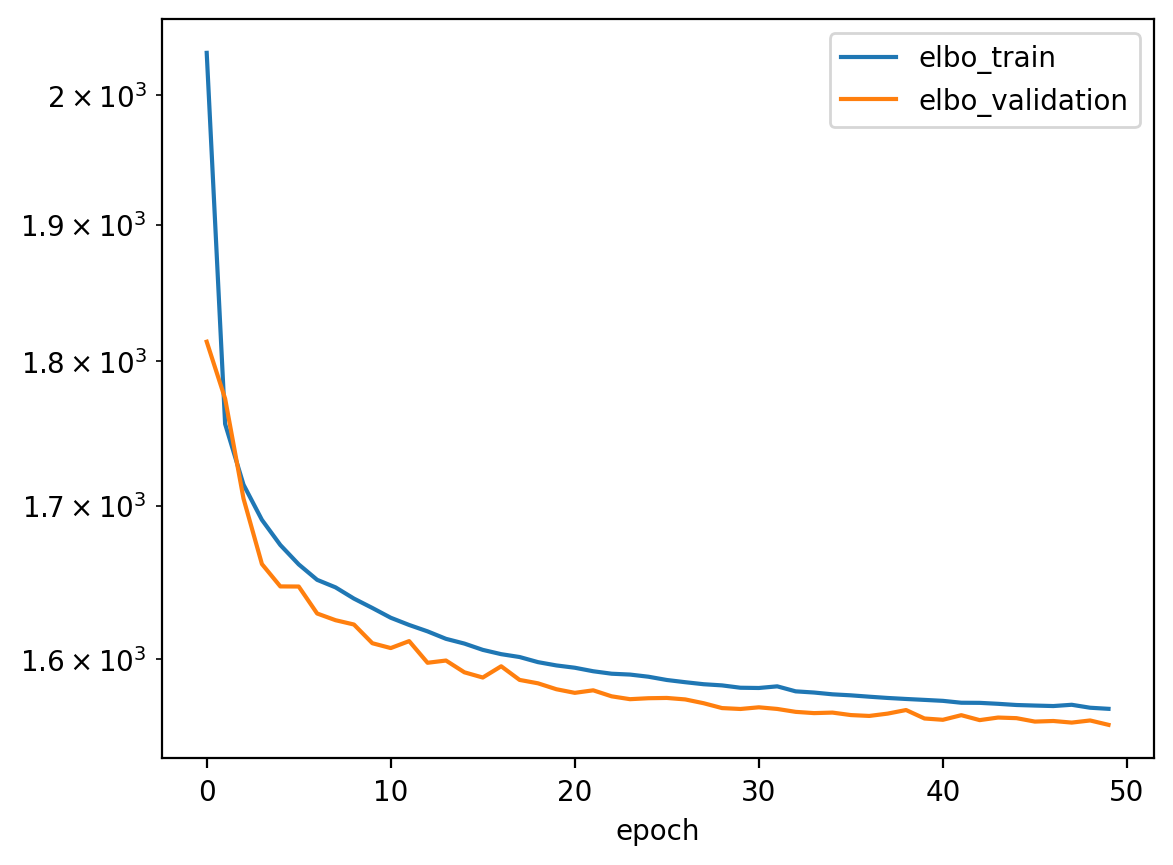

In [8]:
# plot the training/test scores to see if the model finished training, if not do more epochs
train_test_results = model.history['elbo_train']
train_test_results['elbo_validation'] = model.history['elbo_validation']
train_test_results.plot(logy=True)
display(train_test_results)
plt.show()

In [9]:
# this saves the scvi-tools models and the anndata file in a folder
# you only need to train the model once, then can always reload the same model to query it
model.save('cengen_50epochs', save_adata=True )
print('Saved model')

Saved model


In [10]:
## storing the latent space in the anndata allows interoperability with scanpy
adata.obsm["X_scVI"] =  model.get_latent_representation() # get latent
## the latent space by default is 10 dimensional, so it shape should be 10 x ncells
print(adata.obsm["X_scVI"].shape) 

## we can also retrieve the scvi expression rate, akin to normalized expression in other workflows
## however with 100k cells and 11k genes this crahses colab, you should use an instance with more RAM to do this
# adata.layers["scvi_expression_rate"] = model.get_normalized_expression(return_mean=True, return_numpy=True)

(100955, 10)


In [11]:
## Here we define a list of which cells we are interested in making swarm plots for 
## Because the swarmplot requires pairwise DE for all cell types in the dataset, and
## the CeNGEN dataset has 169, it can take a while to generate all the data
## it takes about 30 min per cell type to compute the DE, so we only do it for
## two cell types as an example




# cells_of_interest = ['ADE','ALN','PLN','AQR','CEP','FLP','OLQ','PDE','PHC','PQR','PVD','URB','URY']
## Olivia markers
cells_of_interest = ['ADE',  'ADF',  'ADL',  'AFD',  'AIM',  'AIN',  'ALA',  'ALM',  'ALN',  
              'AQR',  'ASER', 'ASEL',  'ASG',  'ASH',  'ASI',  'ASJ',  'ASK',  'AVE',  'AVG',  
              'AVH',  'AVK',  'AVM',  'AWA',  'AWB',  'AWC_OFF',  'AWC_ON',  
              'BAG',  'CAN',  'CEP',  'DVC',  'FLP',  'I1',  'I2',  'I6',  'IL1',  
              'IL2_DV', 'IL2_LR',  'LUA',  'M3',   'NSM',  'OLQ',  'PDA',  'PDE',  'PHA',  
              'PHB',  'PLM',  'PLN',  'PQR',  'PVC',  'PVD',  'PVM',  'PVQ',  'RIS',  
              'RMD_DV',  'RMG',  'URB',  'URX',  'URY']

#cells_of_interest = ['ASH']
studies_of_interest = ['taylor2020']

## let's check how many cells of the types we are interested in we have in total, per experiment
for celltype in cells_of_interest:
    print('\n=== Number of cells of type ', celltype, ' in each experiment ===')
    print(adata.obs[adata.obs.cell_type==celltype].experiment.value_counts())


=== Number of cells of type  ADE  in each experiment ===
experiment
ceh-28_dat-1    282
Pan-2            70
ift-20           50
Pan-1            48
unc-53            2
ceh-34            1
cho-1_2           1
eat-4             1
tph-1_ceh-10      1
unc-3             1
cho-1_1           0
acr-2             0
nlp-13_ceh-2      0
nmr-1             0
unc-47_1          0
unc-47_2          0
unc-86            0
Name: count, dtype: int64

=== Number of cells of type  ADF  in each experiment ===
experiment
tph-1_ceh-10    464
ift-20          243
Pan-2            16
acr-2            12
eat-4             7
unc-3             3
Pan-1             3
cho-1_2           3
cho-1_1           3
ceh-34            2
ceh-28_dat-1      1
unc-53            1
unc-86            1
nlp-13_ceh-2      0
nmr-1             0
unc-47_1          0
unc-47_2          0
Name: count, dtype: int64

=== Number of cells of type  ADL  in each experiment ===
experiment
ift-20          512
eat-4           330
unc-3            28
P

# Make swarm plots


In [12]:
### This checks how many cells of each type of interest are found in each study
### If there are cells in at least  ~20 cell in each study then it's fine to proceed with
### the differential expression and create the swarm plots
### In this example notebook we only have the CeNGEN dataset, aka taylor2020
print('\n Checking how many `cells_of_interest` are present in each study...')
for study in studies_of_interest:
    print('\n \n 🔹 🔹 🔹 🔹 🔹 🔹 🔹 🔹 Cell counts for:', study, ' 🔹 🔹 🔹 🔹 🔹 🔹 🔹 🔹   ')
    adata_study=adata[adata.obs.study==study]
    for cell_type_1 in cells_of_interest:  
        cell_idx1 = adata_study[adata_study.obs['cell_type'] == cell_type_1].obs.index
        ncells1=len(cell_idx1)
        if ncells1==0:
            ### if the cell type of interest is not present it will print a warning message with the red emojis
            print(' 🛑 🛑 🛑 \t  0 \t', cell_type_1, ' \t cells in ', study, ' \t 🛑 🛑 🛑 ')
            continue
        print(' ✅ ✅ ✅ \t ',ncells1,'\t',  cell_type_1, ' \t cells in ', study, ' \t ✅ ✅ ✅ ')


 Checking how many `cells_of_interest` are present in each study...

 
 🔹 🔹 🔹 🔹 🔹 🔹 🔹 🔹 Cell counts for: taylor2020  🔹 🔹 🔹 🔹 🔹 🔹 🔹 🔹   
 ✅ ✅ ✅ 	  457 	 ADE  	 cells in  taylor2020  	 ✅ ✅ ✅ 
 ✅ ✅ ✅ 	  759 	 ADF  	 cells in  taylor2020  	 ✅ ✅ ✅ 
 ✅ ✅ ✅ 	  955 	 ADL  	 cells in  taylor2020  	 ✅ ✅ ✅ 
 ✅ ✅ ✅ 	  245 	 AFD  	 cells in  taylor2020  	 ✅ ✅ ✅ 
 ✅ ✅ ✅ 	  685 	 AIM  	 cells in  taylor2020  	 ✅ ✅ ✅ 
 ✅ ✅ ✅ 	  522 	 AIN  	 cells in  taylor2020  	 ✅ ✅ ✅ 
 ✅ ✅ ✅ 	  238 	 ALA  	 cells in  taylor2020  	 ✅ ✅ ✅ 
 ✅ ✅ ✅ 	  771 	 ALM  	 cells in  taylor2020  	 ✅ ✅ ✅ 
 ✅ ✅ ✅ 	  28 	 ALN  	 cells in  taylor2020  	 ✅ ✅ ✅ 
 ✅ ✅ ✅ 	  133 	 AQR  	 cells in  taylor2020  	 ✅ ✅ ✅ 
 ✅ ✅ ✅ 	  361 	 ASER  	 cells in  taylor2020  	 ✅ ✅ ✅ 
 ✅ ✅ ✅ 	  195 	 ASEL  	 cells in  taylor2020  	 ✅ ✅ ✅ 
 ✅ ✅ ✅ 	  2312 	 ASG  	 cells in  taylor2020  	 ✅ ✅ ✅ 
 ✅ ✅ ✅ 	  598 	 ASH  	 cells in  taylor2020  	 ✅ ✅ ✅ 
 ✅ ✅ ✅ 	  759 	 ASI  	 cells in  taylor2020  	 ✅ ✅ ✅ 
 ✅ ✅ ✅ 	  1266 	 ASJ  	 cells in  taylor2020  	 ✅ ✅

In [ ]:
## perform DE against ALL cells for swarm plot
## for each cell_type we store the results in the allde dictionary
## each entry of the allde dict is a dataframe with the pairwise DE results 

allde={}

for study in studies_of_interest:
    print('\n \n 🔹 🔹 🔹 🔹 🔹 🔹 🔹 🔹 Cell counts for:', study, ' 🔹 🔹 🔹 🔹 🔹 🔹 🔹 🔹   ')
    adata_study=adata[adata.obs.study==study]
    for cell_type_1 in cells_of_interest:  
        
        cell_idx1 = adata_study[adata_study.obs['cell_type'] == cell_type_1].obs.index
        ncells1=len(cell_idx1)
        if ncells1==0:
            print(' 🛑 🛑 🛑 \t  0 \t', cell_type_1, ' \t cells in ', study, ' \t SKIPPING... 🛑 🛑 🛑 ')
            continue
        print(' ✅ ✅ ✅ \t ',ncells1,'\t',  cell_type_1, ' \t cells in dataset ', study, ' \t  ✅ ✅ ✅ ')
        
        cell_types_in_study = np.sort(adata[adata.obs.study==study].obs.cell_type.unique())
        print('Performing DE for', len(cell_types_in_study), ' distinct cell types in this dataset... ')
        
        allde[cell_type_1+study]=pd.DataFrame()  
        for cell_type_2 in tqdm(cell_types_in_study):

            cell_idx2 = adata_study[adata_study.obs['cell_type'] == cell_type_2].obs.index
            ncells2=len(cell_idx2)
            # print(ncells2, ' \t ' +  str(cell_type_2) +  '  \t \t  \t vs  ', ncells1, cell_type_1, ' in ', study)

            if cell_type_1==cell_type_2:
#                 print(cell_type_1, cell_type_2, '...skipping...')
                continue
            ###### DE CHANGE ############
            de = model.differential_expression(
                idx1 = adata.obs.index.isin(cell_idx1), 
                idx2 = adata.obs.index.isin(cell_idx2), 
                mode='change',
                silent=True
                )
            de['comparison']=cell_type_2
            # allde[cell_type_1+study] = allde[cell_type_1+study].append(de) # OLD 2021 CODE
            allde[cell_type_1+study] = pd.concat([de, allde[cell_type_1+study]], ignore_index=False) # NEW 2025 CODE FIXED
            
        ### Save DE results in one folder per cell type per study    
        savename = 'DE_results_' + cell_type_1+'_'+ study
#         if not os.path.exists(savename): os.makedirs(savename)    
        allde[cell_type_1+study].to_csv(savename+'.csv')
        savename2= 'globalde'+celltype+'taylor2020.csv'
        allde[cell_type_1+study].to_csv(savename2)


 
 🔹 🔹 🔹 🔹 🔹 🔹 🔹 🔹 Cell counts for: taylor2020  🔹 🔹 🔹 🔹 🔹 🔹 🔹 🔹   
 ✅ ✅ ✅ 	  457 	 ADE  	 cells in dataset  taylor2020  	  ✅ ✅ ✅ 
Performing DE for 169  distinct cell types in this dataset... 


100%|█████████████████████████████████████████| 169/169 [07:47<00:00,  2.77s/it]


 ✅ ✅ ✅ 	  759 	 ADF  	 cells in dataset  taylor2020  	  ✅ ✅ ✅ 
Performing DE for 169  distinct cell types in this dataset... 


100%|█████████████████████████████████████████| 169/169 [07:43<00:00,  2.74s/it]


 ✅ ✅ ✅ 	  955 	 ADL  	 cells in dataset  taylor2020  	  ✅ ✅ ✅ 
Performing DE for 169  distinct cell types in this dataset... 


100%|█████████████████████████████████████████| 169/169 [07:50<00:00,  2.79s/it]


 ✅ ✅ ✅ 	  245 	 AFD  	 cells in dataset  taylor2020  	  ✅ ✅ ✅ 
Performing DE for 169  distinct cell types in this dataset... 


 28%|███████████▋                              | 47/169 [02:06<05:35,  2.75s/it]

In [ ]:
# downloads a file that maps gene names to gene id and puts that in a dataframe
# the genemaps is used to add the gene names
!wget -nc https://raw.githubusercontent.com/Munfred/worm-markers/master/worm_gene_name_id.csv
genemaps = pd.read_csv('./worm_gene_name_id.csv', index_col=1)
name2id=genemaps.set_index('gene_name')
name2id['gene_id']=genemaps.index


In [ ]:
# finally combine all this information to make the swarm plots
# we use plotly to make the interactive scatter plot, to learn how to tweak 
# the plot see the documentation at 
# https://plotly.com/python/line-and-scatter/
globalde=allde
dedfs = globalde
for study in studies_of_interest:
    # makes two plots, one with top 50 and one with top 100, you can add more genes if needed
    for n_top_selection in [50]:
        print('\n \n 🔹 🔹 🔹 🔹 🔹 🔹 🔹 🔹 Cell counts for:', study, ' 🔹 🔹 🔹 🔹 🔹 🔹 🔹 🔹   ')
        # if you have multiple studies in the anndata object, select only one
        adata_study=adata[adata.obs.study==study]
        # then loop through each cell of interst
        for cell_type_1 in cells_of_interest:  
            cell_idx1 = adata_study[adata_study.obs['cell_type'] == cell_type_1].obs.index
            ncells1=len(cell_idx1)
            if ncells1==0:
                print(' 🛑 🛑 🛑 \t  0 \t', cell_type_1, ' \t cells in ', study, ' \t SKIPPING... 🛑 🛑 🛑 ')
                continue
            print(' ✅ ✅ ✅ \t ',ncells1,'\t',  cell_type_1, ' \t cells in ', study, ' \t MAKING SWARM PLOT FOR... ✅ ✅ ✅ ')
            cell_types_in_study = np.sort(adata[adata.obs.study==study].obs.cell_type.unique())
            print(len(cell_types_in_study), ' CELL TYPES ')

            # sort display order by median log fold change
            # select positive lfc
            sel=dedfs[cell_type_1+study][dedfs[cell_type_1+study].lfc_mean>0].copy()
            sel['gene_id']=sel.index
            # sort by p value, select top n
            sel = sel.sort_values(by='proba_not_de', ascending=True).head(n_top_selection)

            # if you want you can extra genes to be included in the plot with the list
            # list_of_genes_to_color, they can be highlighted as red
            # uncommeting the other blow below
            # markersdf = dedfs[cell_type_1+study][dedfs[cell_type_1+study].index.isin(list_of_genes_to_color)].copy()    

            sel['gene_id']=sel.index
            sel_genes=sel['gene_id']

            # now create the plotly plot
            # `data` contains each gene to plot
            data = []    
            for gene_id, _gene_id in sel_genes[::-1].items():
                gene_name=genemaps.loc[gene_id]['gene_name']

                dedf=allde[cell_type_1+study][allde[cell_type_1+study].index==gene_id].copy()
                color = 'rgb(0, 0, 0)'
                
                # add a list of gene ids to a list called `list_of_genes_to_color` and
                # uncomment the line below to highlight those genes in red
                #if gene_id in list_of_genes_to_color: 
                #    color = 'rgb(255, 0, 0)'

                trace = go.Box(
                 x=-np.round(dedf['lfc_mean'],3), boxpoints = 'all', pointpos = 0
                , marker = dict(color = color)
                , line = dict(color = 'rgba(0,0,0,0)')
                , fillcolor = 'rgba(0,0,0,0)'
                , opacity=1
                , marker_size=4  
                , name = gene_name  + ' \t \t \t expression rate = 10^' + str(np.round(np.log10(dedf['scale1'][0]),1)) #+ ' | p=' + f"{sel[sel.gene_id==gene_id]['proba_not_de'][0]:.1E}"
                , hoverinfo='text'
                , text= 'Cell type: ' + dedf['comparison'].values +'<br>' +'Gene: ' + gene_name + '<br>'+ dedf['comparison'].values + ' expression: 10^'+pd.Series(np.round(np.log10(dedf['scale2'].values),1).astype(str))
                , customdata=cell_type_1 + ' expression rate: 10^'+ pd.Series(np.round(np.log10(dedf['scale1'].values),1).astype(str)) +"<br>log2 fold change: " 
                    + np.round(dedf['lfc_median'].values,1).astype(str)
                , hovertemplate='%{text}<br>%{customdata} ' +
                                ' ' +'<extra></extra>'
                )
                data.append(trace)
            title= ' Relative log fold change in expression of top ' +str(n_top_selection) + ' ' + cell_type_1 + ' specific genes in ' + study
            layout = go.Layout(title=title
                             # uncomment the line below to fix the plot width
                             # , width=750
                               , height=n_top_selection*23
                              )
            fig = go.Figure(data, layout)
            fig.update_layout(showlegend=False, template='none', xaxis_title="log2 fold change relative to expression in "+cell_type_1,)
            fig.update_xaxes(tickangle=90, tickfont=dict( color='black', size=12),automargin=True)
            fig.update_yaxes(automargin=True)
            fig.update_layout(hovermode="closest")

            # create a folder and save the topN plots on that folder
            folder_name='top'+str(n_top_selection)
            html_title='./'+folder_name+'/' + cell_type_1+study + '_top'+str(n_top_selection)+'genes_swarmplot.html'
            print(title)
            if not os.path.exists(folder_name): 
                os.makedirs(folder_name)

            # comment the line below to not save
            fig.write_html(html_title)

            # this will show the plotly plot on jupyter
            fig.show()
print('DONE!')

In [ ]:

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# Control warnings
import warnings; warnings.simplefilter('ignore')

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import torch
import anndata
from tqdm import tqdm
from umap import UMAP
from openTSNE import TSNE
import scanpy as sc 
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import Image
import scvi
print('You are using scvi-tools version:',scvi.__version__)


from matplotlib import cm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import itertools

In [ ]:
# downloads a file that maps gene names to gene id and puts that in a dataframe
# the genemaps is used to add the gene names
!wget -nc https://raw.githubusercontent.com/Munfred/worm-markers/master/worm_gene_name_id.csv
genemaps = pd.read_csv('./worm_gene_name_id.csv', index_col=1)
name2id=genemaps.set_index('gene_name')
name2id['gene_id']=genemaps.index

In [ ]:
ntop=25
for celltype in cells_of_interest:
    print(celltype)

    topde=pd.read_csv('globalde'+celltype+'taylor2020.csv')
    topde

    colors = itertools.cycle(["yellowgreen", 'cornflowerblue'])


    n_genes_selected=25

    global_de=pd.read_csv('globalde'+celltype+'taylor2020.csv')
    # select only negative logfold change genes
    negative_lfc_genes=global_de[global_de['lfc_mean']>0]
    #within negative lfc genes, sort by p value, then reindex them with lowest p value being ranked first 
    topgenes=negative_lfc_genes.sort_values(by='proba_not_de')['gene_id'][:ntop].iloc[::-1].reset_index(drop=True)
    topgenes.index += 1 
    # topgenes=pd.Series(sel.index)

    pairwise_de=pd.read_csv('DE_results_'+celltype+'_taylor2020.csv', index_col=0)
    pairwise_de
    # pairwise_de_selection = pairwise_de[pairwise_de['gene_id'].isin(topgenes)]
    pairwise_de_selection = pairwise_de[pairwise_de.index.isin(topgenes)]
    pairwise_de_selection

    # topgenes=sel.index
    de_topgenes=global_de[global_de['gene_id'].isin(topgenes)]

    # definitions for the axes
    left, width = 0.1, 0.65
    bottom, height = 0.1, 0.65
    spacing = 0.0

    rect_scatter = [left, bottom, width, height]
    rect_left = [ -left  + spacing, bottom, 0.2, height]
    rect_right = [left + width + spacing, bottom, 0.2, height]

    # start with a square Figure
    fig = plt.figure(figsize=(8, 12), dpi=100)

    ax = fig.add_axes(rect_scatter)
    ax_left = fig.add_axes(rect_left, sharey=ax)
    ax_right = fig.add_axes(rect_right, sharey=ax)

    ax.axes.yaxis.set_visible(False)
    ax_left.axes.yaxis.set_visible(False)
    ax_right.axes.yaxis.set_visible(False)


    for rank, gene_id in topgenes.items():
        color=next(colors)
        # gene_expression_values = pairwise_de_selection[pairwise_de_selection['gene_id']==gene_id]
        gene_expression_values = pairwise_de_selection[pairwise_de_selection.index==gene_id]

        ax.scatter(-gene_expression_values['lfc_mean'], [rank]*len(gene_expression_values), c=color, alpha=0.6, s = 30, edgecolors='none')
        expression=de_topgenes.query('gene_id==@gene_id')['scale1'].values
        pvalue=de_topgenes.query('gene_id==@gene_id')['proba_not_de'].values
        ax_right.barh(rank,expression , color=color)
        ax_left.barh(rank,pvalue , color=color)
        ax_left.text(0, rank-0.18,'  '+ genemaps.loc[gene_id][0])
    #     ax_right.text(ax_right.get_xlim()[0], rank,' foo')

    ax.title.set_text('Log2 fold change relative expression in ' +celltype +' \n of top '+ str(n_genes_selected) + ' DE genes')
    ax_left.title.set_text('DE p-value')
    ax_right.title.set_text(celltype + ' expression')

    ax_left.grid(True, ls = '--')
    ax_right.grid(True, ls = '--')
    # ax_left.set_xscale('log')
    ax_right.set_xscale('log')
    ax.set_xlim(left=-9, right = 9)
    # ax.set_xlabel('Log2 fold change relative to cell expression in ' +celltype)
    # ax_left.set_xlabel('common label')
    # ax_right.set_xlabel('common label')
    # ax_left.xaxis.set_major_locator(plt.MaxNLocator(1))
    # ax_right.xaxis.set_major_locator(plt.MaxNLocator(1))
    ax_left.xaxis.set_minor_locator(plt.MaxNLocator(2))
    ax_right.xaxis.set_minor_locator(plt.MaxNLocator(2))
    ax_left.set_xlim(left=0, right = 0.01)
    ax_right.set_xlim(left=10e-6, right = 10e-2)

    ax.grid(True, ls = '--')
    ax.axvline(x=0, color='k', linestyle='--')
    plt.savefig('./'+celltype+'_nice_swarmplot.png', dpi=150)
    plt.show()